# Dataset visualisation

       age      workclass      education  education-num       marital-status  \
0       25        Private           11th              7        Never-married   
1       38        Private        HS-grad              9   Married-civ-spouse   
2       28      Local-gov     Assoc-acdm             12   Married-civ-spouse   
3       44        Private   Some-college             10   Married-civ-spouse   
4       18              ?   Some-college             10        Never-married   
...    ...            ...            ...            ...                  ...   
48837   27        Private     Assoc-acdm             12   Married-civ-spouse   
48838   40        Private        HS-grad              9   Married-civ-spouse   
48839   58        Private        HS-grad              9              Widowed   
48840   22        Private        HS-grad              9        Never-married   
48841   52   Self-emp-inc        HS-grad              9   Married-civ-spouse   

               occupation relationship 

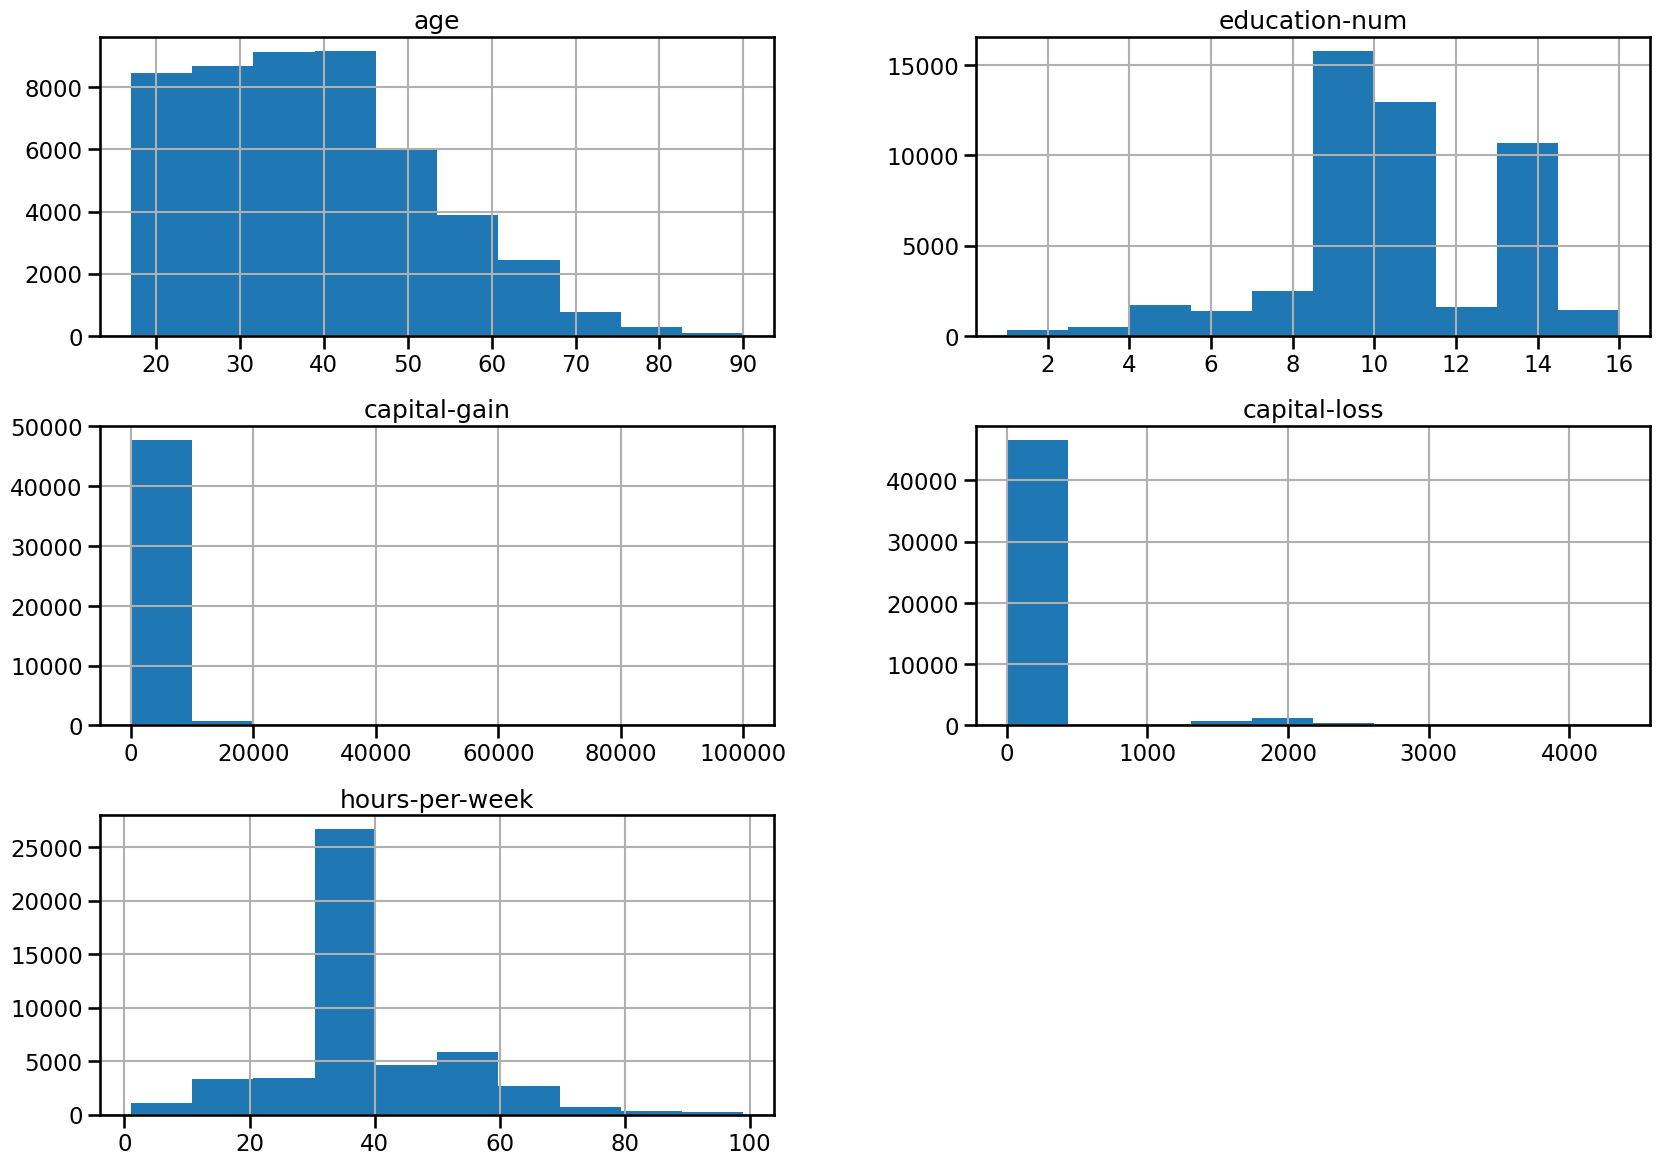

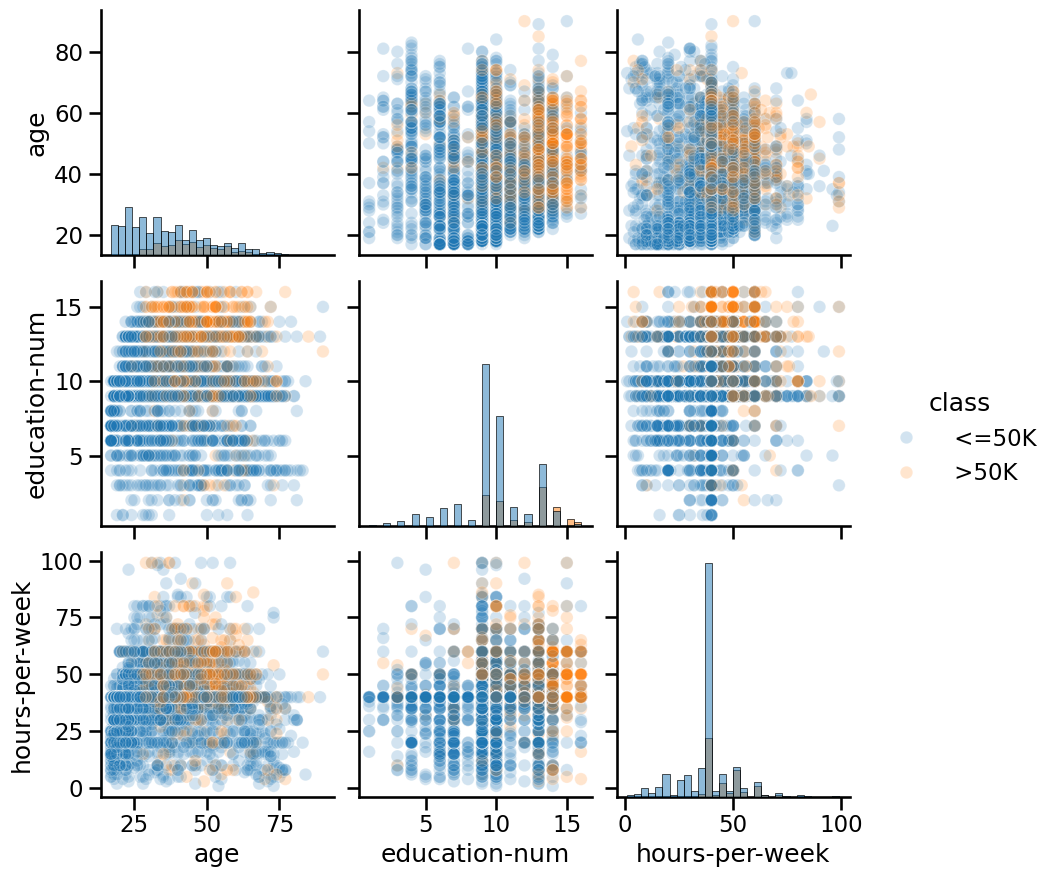

In [3]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")
# Show the dataset
print(adult_census)
# Give information about the columns and the data types
print(adult_census.info())
# Show the statistical summary of the dataset
print(adult_census.describe())


# Show the number of unique values in each column
print(adult_census.nunique())
# Show the distribution of the target variable
target_column = "class"
print(adult_census[target_column].value_counts())
# Show the distribution of the numerical features
_ = adult_census.hist(figsize=(20, 14))
# Show the correlation between two feautures
pd.crosstab(
    index=adult_census["education"], columns=adult_census["education-num"]
)

import seaborn as sns
# We plot a subset of the data to keep the plot readable and make the plotting
# faster
n_samples_to_plot = 5000
columns = ["age", "education-num", "hours-per-week"]
_ = sns.pairplot(
    data=adult_census[:n_samples_to_plot],
    vars=columns,
    hue=target_column,
    plot_kws={"alpha": 0.2},
    height=3,
    diag_kind="hist", # hist or kde (kernel density estimation)
    diag_kws={"bins": 30},
)

Handmade rules visualisation

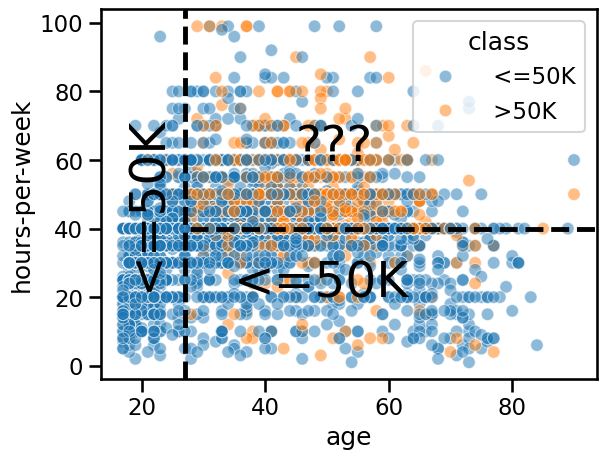

In [4]:
import matplotlib.pyplot as plt

ax = sns.scatterplot(
    x="age",
    y="hours-per-week",
    data=adult_census[:n_samples_to_plot],
    hue=target_column,
    alpha=0.5,
)

age_limit = 27
plt.axvline(x=age_limit, ymin=0, ymax=1, color="black", linestyle="--")

hours_per_week_limit = 40
plt.axhline(
    y=hours_per_week_limit, xmin=0.18, xmax=1, color="black", linestyle="--"
)

plt.annotate("<=50K", (17, 25), rotation=90, fontsize=35)
plt.annotate("<=50K", (35, 20), fontsize=35)
_ = plt.annotate("???", (45, 60), fontsize=35)

# pipeline

In [5]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")
# drop the duplicated column `"education-num"` as stated in the first notebook
adult_census = adult_census.drop(columns="education-num")

target_name = "class"
target = adult_census[target_name]

data = adult_census.drop(columns=[target_name])

# Select numerical and categorical columns using the make_column_selector helper function
from sklearn.compose import make_column_selector as selector

numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(data)
categorical_columns = categorical_columns_selector(data)

# Create seperate preprocessors for numerical and categorical columns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()

# Combine the preprocessors using the make_column_transformer helper function
from sklearn.compose import make_column_transformer

preprocessor = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    (numerical_preprocessor, numerical_columns),
)

# Create the model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(preprocessor, LogisticRegression(max_iter=500))
print(model.named_steps)

# Split the data into a training set and a test set
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
)

# Cross validate the model on the training set
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, data, target, cv=5)
cv_results

{'columntransformer': ColumnTransformer(transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country']),
                                ('standardscaler', StandardScaler(),
                                 ['age', 'capital-gain', 'capital-loss',
                                  'hours-per-week'])]), 'logisticregression': LogisticRegression(max_iter=500)}


{'fit_time': array([0.18401241, 0.19508624, 0.17073488, 0.17955875, 0.20358372]),
 'score_time': array([0.01843858, 0.01972938, 0.01913261, 0.01978469, 0.01850009]),
 'test_score': array([0.85116184, 0.84993346, 0.8482801 , 0.85257985, 0.85544636])}

## Evaluation

In [6]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
data, target = housing.data, housing.target
print(housing.DESCR)
target *= 100
print(f"data: \n{data}")
print(f"target: \n{target}")

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(random_state=0)

from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=40, test_size=0.3, random_state=0)
cv_results = cross_validate(
    regressor, data, target, cv=cv, scoring="neg_mean_absolute_percentage_error"
)
cv_results = pd.DataFrame(cv_results)
cv_results["test_error"] = -cv_results["test_score"]

In [8]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
)
regressor.fit(data_train, target_train)
regressor.score(data_test, target_test)

0.6053924792647187

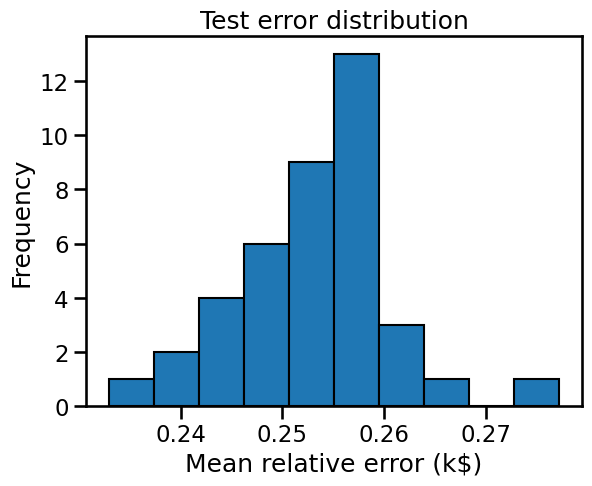

In [9]:
import matplotlib.pyplot as plt

cv_results["test_error"].plot.hist(bins=10, edgecolor="black")
plt.xlabel("Mean relative error (k$)")
_ = plt.title("Test error distribution")

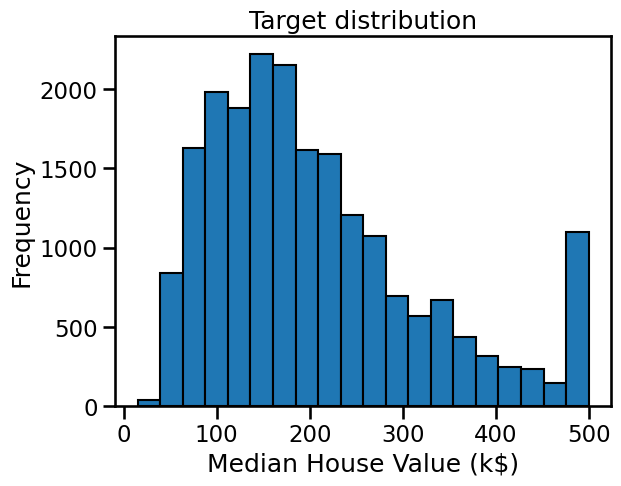

In [10]:
target.plot.hist(bins=20, edgecolor="black")
plt.xlabel("Median House Value (k$)")
_ = plt.title("Target distribution")

# Single hyperparameter curve display

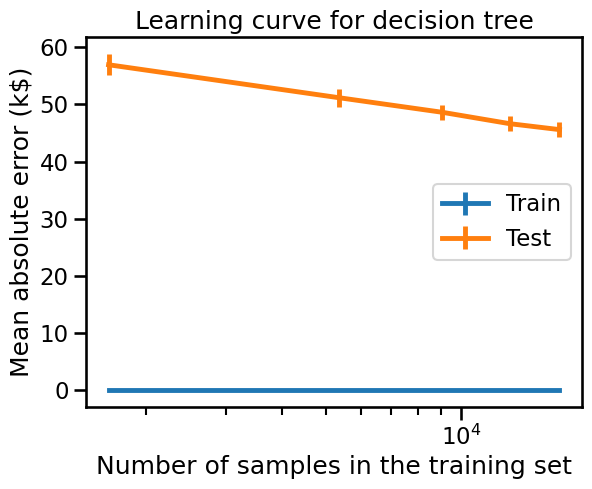

In [11]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
data, target = housing.data, housing.target
target *= 100  # rescale the target in k$
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()
import numpy as np

train_sizes = np.linspace(0.1, 1.0, num=5, endpoint=True)
train_sizes
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=30, test_size=0.2)
from sklearn.model_selection import LearningCurveDisplay

display = LearningCurveDisplay.from_estimator(
    regressor,
    data,
    target,
    train_sizes=train_sizes,
    cv=cv,
    score_type="both",  # both train and test errors
    scoring="neg_mean_absolute_error",
    negate_score=True,  # to use when metric starts with "neg_"
    score_name="Mean absolute error (k$)",
    std_display_style="errorbar",
    n_jobs=2,
)
_ = display.ax_.set(xscale="log", title="Learning curve for decision tree")

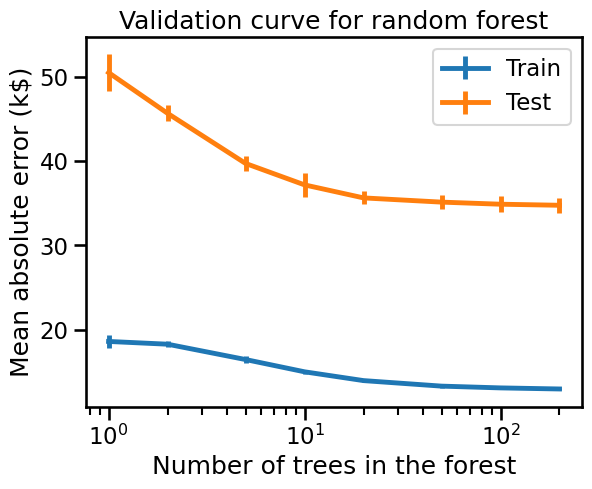

In [12]:
# Write your code here.
import numpy as np
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing

data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100  # rescale the target in k$
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0, test_size=0.5
)
forest = RandomForestRegressor(max_depth=None)
param_range = np.array([1, 2, 5, 10, 20, 50, 100, 200])

display = ValidationCurveDisplay.from_estimator(
    forest,
    data_train, 
    target_train, 
    param_name="n_estimators",
    param_range=param_range,
    scoring="neg_mean_absolute_error",
    negate_score=True,
    score_name="Mean absolute error (k$)",
    std_display_style="errorbar",
    n_jobs=2
)

_ = display.ax_.set(
    xlabel="Number of trees in the forest",
    ylabel="Mean absolute error (k$)",
    title="Validation curve for random forest",
)

# Hyperparameter optimization

In [13]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")

target_name = "class"
numerical_columns = ["age", "capital-gain", "capital-loss", "hours-per-week"]

target = adult_census[target_name]
data = adult_census[numerical_columns]

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", StandardScaler()),
        ("classifier", LogisticRegression()),
    ]
)

In [15]:
# Access model parameters
model.get_params()

{'memory': None,
 'steps': [('preprocessor', StandardScaler()),
  ('classifier', LogisticRegression())],
 'transform_input': None,
 'verbose': False,
 'preprocessor': StandardScaler(),
 'classifier': LogisticRegression(),
 'preprocessor__copy': True,
 'preprocessor__with_mean': True,
 'preprocessor__with_std': True,
 'classifier__C': 1.0,
 'classifier__class_weight': None,
 'classifier__dual': False,
 'classifier__fit_intercept': True,
 'classifier__intercept_scaling': 1,
 'classifier__l1_ratio': 0.0,
 'classifier__max_iter': 100,
 'classifier__n_jobs': None,
 'classifier__penalty': 'deprecated',
 'classifier__random_state': None,
 'classifier__solver': 'lbfgs',
 'classifier__tol': 0.0001,
 'classifier__verbose': 0,
 'classifier__warm_start': False}

## Gridsearch

In [16]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")

target_name = "class"
target = adult_census[target_name]
data = adult_census.drop(columns=[target_name, "education-num"])

from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
)

from sklearn.compose import make_column_selector as selector

categorical_columns_selector = selector(dtype_include=object)
categorical_columns = categorical_columns_selector(data)

from sklearn.preprocessing import OrdinalEncoder

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)

from sklearn.compose import make_column_transformer

preprocessor = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    remainder="passthrough",
)

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(random_state=42, max_leaf_nodes=4),
        ),
    ]
)

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__learning_rate": (0.01, 0.1, 1, 10),  # 4 possible values
    "classifier__max_leaf_nodes": (3, 10, 30),  # 3 possible values
}  # 12 unique combinations
model_grid_search = GridSearchCV(model, param_grid=param_grid, n_jobs=2, cv=2)
_ = model_grid_search.fit(data_train, target_train)

In [18]:
print(f"The best set of parameters is: {model_grid_search.best_params_}")

accuracy = model_grid_search.score(data_test, target_test)
print(
    f"The test accuracy score of the grid-search pipeline is: {accuracy:.2f}"
)

The best set of parameters is: {'classifier__learning_rate': 0.1, 'classifier__max_leaf_nodes': 30}
The test accuracy score of the grid-search pipeline is: 0.88


In [19]:
cv_results = pd.DataFrame(model_grid_search.cv_results_).sort_values(
    "mean_test_score", ascending=False
)
# get the parameter names
column_results = [f"param_{name}" for name in param_grid.keys()]
column_results += ["mean_test_score", "std_test_score", "rank_test_score"]
cv_results = cv_results[column_results]

def shorten_param(param_name):
    if "__" in param_name:
        return param_name.rsplit("__", 1)[1]
    return param_name


cv_results = cv_results.rename(shorten_param, axis=1)
cv_results

pivoted_cv_results = cv_results.pivot_table(
    values="mean_test_score",
    index=["learning_rate"],
    columns=["max_leaf_nodes"],
)

pivoted_cv_results

max_leaf_nodes,3,10,30
learning_rate,,,
0.01,0.797166,0.817832,0.843330
0.10,0.853266,0.866425,0.868063
1.00,0.857389,0.858863,0.851028
10.00,0.283476,0.618080,0.549338


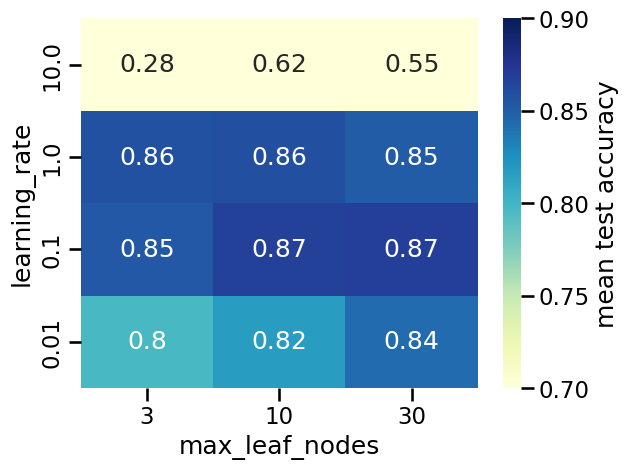

In [20]:
import seaborn as sns

ax = sns.heatmap(
    pivoted_cv_results,
    annot=True,
    cmap="YlGnBu",
    vmin=0.7,
    vmax=0.9,
    cbar_kws={"label": "mean test accuracy"},
)
ax.invert_yaxis()

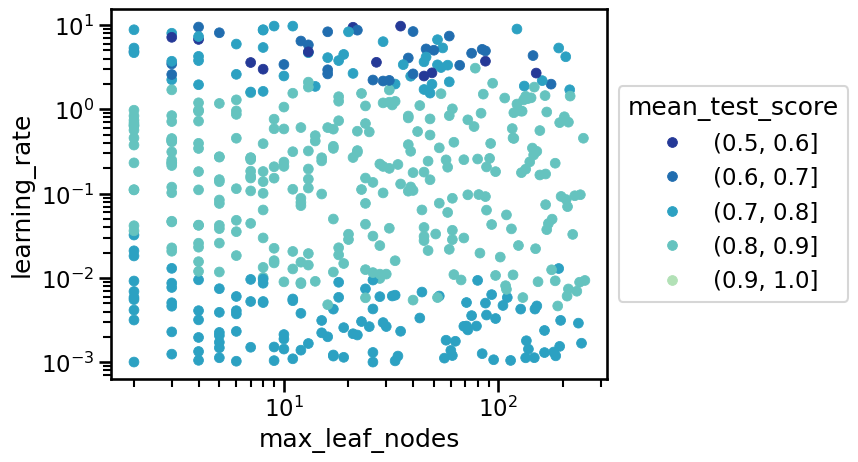

In [21]:
import pandas as pd

cv_results = pd.read_csv(
    "../figures/randomized_search_results.csv", index_col=0
)

def shorten_param(param_name):
    if "__" in param_name:
        return param_name.rsplit("__", 1)[1]
    return param_name


cv_results = cv_results.rename(shorten_param, axis=1)

import seaborn as sns
import numpy as np

df = pd.DataFrame(
    {
        "max_leaf_nodes": cv_results["max_leaf_nodes"],
        "learning_rate": cv_results["learning_rate"],
        "score_bin": pd.cut(
            cv_results["mean_test_score"], bins=np.linspace(0.5, 1.0, 6)
        ),
    }
)
sns.set_palette("YlGnBu_r")
ax = sns.scatterplot(
    data=df,
    x="max_leaf_nodes",
    y="learning_rate",
    hue="score_bin",
    s=50,
    color="k",
    edgecolor=None,
)
ax.set_xscale("log")
ax.set_yscale("log")

_ = ax.legend(
    title="mean_test_score", loc="center left", bbox_to_anchor=(1, 0.5)
)

## Parallel coordinates plot

In [22]:
import numpy as np
import plotly.express as px

fig = px.parallel_coordinates(
    cv_results.rename(shorten_param, axis=1).apply(
        {
            "learning_rate": np.log10,
            "max_leaf_nodes": np.log2,
            "max_bins": np.log2,
            "min_samples_leaf": np.log10,
            "l2_regularization": np.log10,
            "mean_test_score": lambda x: x,
        }
    ),
    color="mean_test_score",
    color_continuous_scale=px.colors.sequential.Viridis,
)
fig.show(renderer="notebook")

# Non linearity

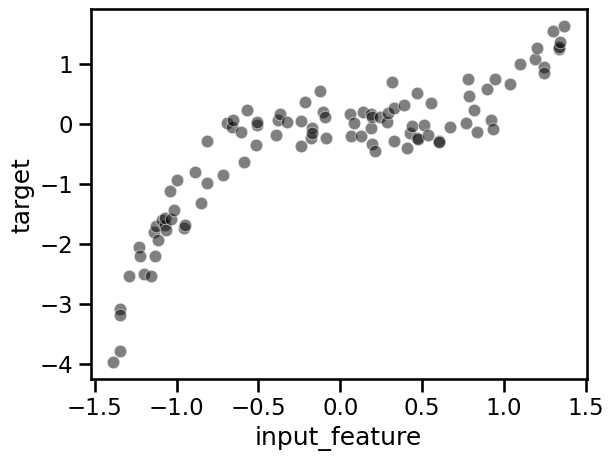

In [23]:
import numpy as np

rng = np.random.RandomState(0)

n_sample = 100
data_max, data_min = 1.4, -1.4
len_data = data_max - data_min
# sort the data to make plotting easier later
data = np.sort(rng.rand(n_sample) * len_data - len_data / 2)
noise = rng.randn(n_sample) * 0.3
target = data**3 - 0.5 * data**2 + noise

import pandas as pd

full_data = pd.DataFrame({"input_feature": data, "target": target})

import seaborn as sns

_ = sns.scatterplot(
    data=full_data, x="input_feature", y="target", color="black", alpha=0.5
)

In [24]:
# X should be 2D for sklearn: (n_samples, n_features)
data = data.reshape((-1, 1))

In [25]:
from sklearn.metrics import mean_squared_error


def fit_score_plot_regression(model, title=None):
    model.fit(data, target)
    target_predicted = model.predict(data)
    mse = mean_squared_error(target, target_predicted)
    ax = sns.scatterplot(
        data=full_data, x="input_feature", y="target", color="black", alpha=0.5
    )
    ax.plot(data, target_predicted)
    if title is not None:
        _ = ax.set_title(title + f" (MSE = {mse:.2f})")
    else:
        _ = ax.set_title(f"Mean squared error = {mse:.2f}")

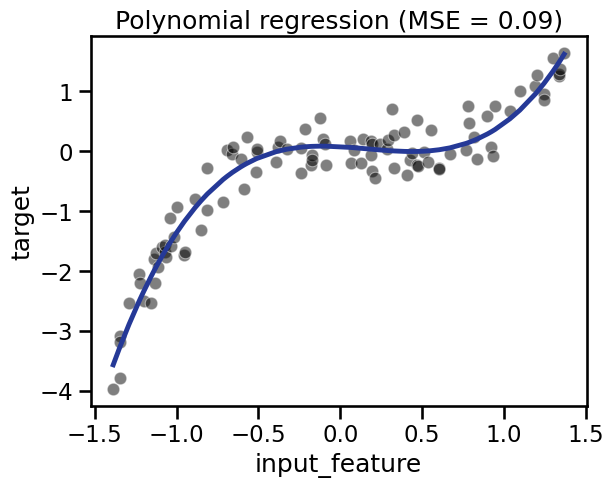

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression(),
)
fit_score_plot_regression(polynomial_regression, title="Polynomial regression")

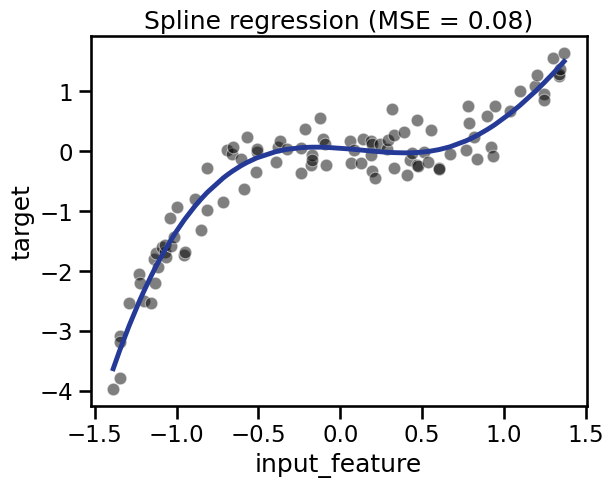

In [27]:
from sklearn.preprocessing import SplineTransformer

spline_regression = make_pipeline(
    SplineTransformer(degree=3, include_bias=False),
    LinearRegression(),
)
fit_score_plot_regression(spline_regression, title="Spline regression")

# Inspect coefficients

In [28]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")
target = adult_census["class"]
data = adult_census.select_dtypes(["integer", "floating"])
data = data.drop(columns=["education-num"])
data

,age,capital-gain,capital-loss,hours-per-week
0,25,0,0,40
1,38,0,0,50
2,28,0,0,40
3,44,7688,0,40
4,18,0,0,30
...,...,...,...,...
48837,27,0,0,38
48838,40,0,0,40
48839,58,0,0,40
48840,22,0,0,20


In [29]:
# Write your code here.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

pipeline = make_pipeline(StandardScaler(), LogisticRegression())

cv_results = cross_validate(pipeline, data, target, cv=10, return_estimator=True)
cv_results

{'fit_time': array([0.04434681, 0.0388844 , 0.04284501, 0.04123807, 0.04350233,
        0.04122877, 0.04130983, 0.04187775, 0.03963447, 0.04605341]),
 'score_time': array([0.00452542, 0.00455284, 0.00521183, 0.00468969, 0.00414777,
        0.0045557 , 0.00479674, 0.0042696 , 0.0048418 , 0.00540447]),
 'estimator': [Pipeline(steps=[('standardscaler', StandardScaler()),
                  ('logisticregression', LogisticRegression())]),
  Pipeline(steps=[('standardscaler', StandardScaler()),
                  ('logisticregression', LogisticRegression())]),
  Pipeline(steps=[('standardscaler', StandardScaler()),
                  ('logisticregression', LogisticRegression())]),
  Pipeline(steps=[('standardscaler', StandardScaler()),
                  ('logisticregression', LogisticRegression())]),
  Pipeline(steps=[('standardscaler', StandardScaler()),
                  ('logisticregression', LogisticRegression())]),
  Pipeline(steps=[('standardscaler', StandardScaler()),
                  (

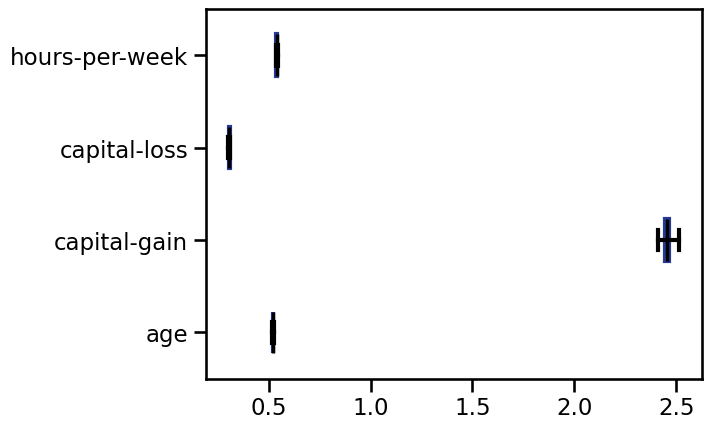

In [30]:
# Write your code here.
import matplotlib.pyplot as plt
coefs = [pipeline[-1].coef_[0] for pipeline in cv_results["estimator"]]
coefs = pd.DataFrame(coefs, columns=data.columns)

color = {"whiskers": "black", "medians": "black", "caps": "black"}
_, ax = plt.subplots()
_ = coefs.abs().plot.box(color=color, vert=False, ax=ax)

# Compare folds

A model using both all features is better than a model using only numerical features for 10 CV iterations out of 10.


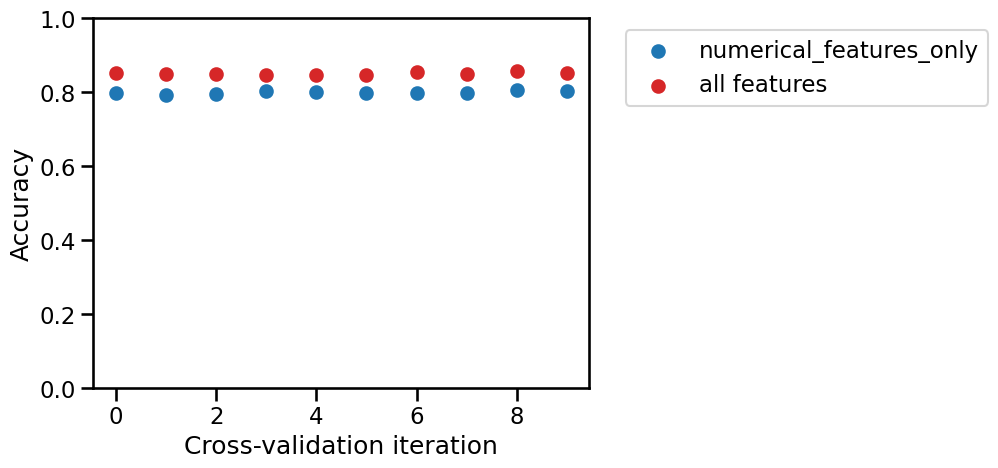

In [31]:
adult_census = pd.read_csv("../datasets/adult-census.csv")
target = adult_census["class"]
data = adult_census.drop(columns=["class", "education-num"])

# Write your code here.
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import make_column_transformer

numerical_column_selector = selector(dtype_exclude=object)
categorical_column_selector = selector(dtype_include=object)

numerical_columns = numerical_column_selector(data)
categorical_columns = categorical_column_selector(data)

categorical_preprocessor = OneHotEncoder(min_frequency=0.01, handle_unknown="ignore")
numerical_preprocessor = StandardScaler()

preprocessor = make_column_transformer(
    (numerical_preprocessor, numerical_columns),
    (categorical_preprocessor, categorical_columns),
)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(preprocessor, LogisticRegression(max_iter=5_000))

from sklearn.model_selection import cross_validate

cv_results_2 = cross_validate(model, data, target, cv=10, return_estimator=True, n_jobs=2)
test_score_lr = cv_results_2["test_score"]

# Write your code here.
import numpy as np
indices = np.arange(len(test_score_lr))
plt.scatter(indices, cv_results["test_score"], color="tab:blue", label="numerical_features_only")
plt.scatter(indices, test_score_lr, color="tab:red", label="all features")
plt.ylim((0, 1))
plt.xlabel("Cross-validation iteration")
plt.ylabel("Accuracy")
_ = plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

print(
    "A model using both all features is better than a"
    " model using only numerical features for"
    f" {sum(test_score_lr > cv_results["test_score"])} CV iterations out of 10."
)

# Nystroem classifier

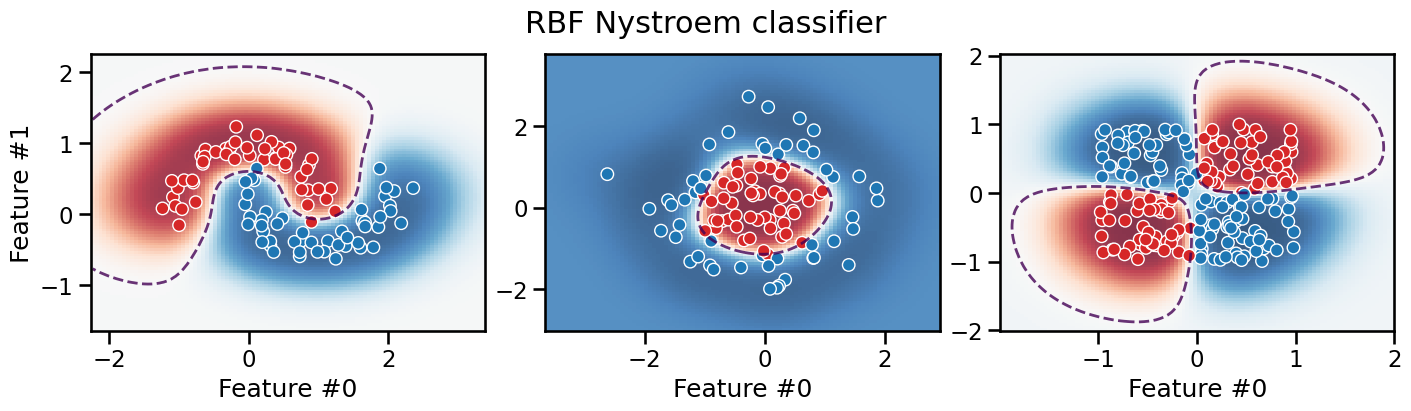

In [32]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons

feature_names = ["Feature #0", "Feature #1"]
target_name = "class"

X, y = make_moons(n_samples=100, noise=0.13, random_state=42)

# We store both the data and target in a dataframe to ease plotting
moons = pd.DataFrame(
    np.concatenate([X, y[:, np.newaxis]], axis=1),
    columns=feature_names + [target_name],
)
data_moons, target_moons = moons[feature_names], moons[target_name]

from sklearn.datasets import make_gaussian_quantiles

X, y = make_gaussian_quantiles(
    n_samples=100, n_features=2, n_classes=2, random_state=42
)
gauss = pd.DataFrame(
    np.concatenate([X, y[:, np.newaxis]], axis=1),
    columns=feature_names + [target_name],
)
data_gauss, target_gauss = gauss[feature_names], gauss[target_name]

xor = pd.DataFrame(
    np.random.RandomState(0).uniform(low=-1, high=1, size=(200, 2)),
    columns=feature_names,
)
target_xor = np.logical_xor(xor["Feature #0"] > 0, xor["Feature #1"] > 0)
target_xor = target_xor.astype(np.int32)
xor["class"] = target_xor
data_xor = xor[feature_names]

from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap

common_scatter_plot_params = dict(
    cmap=ListedColormap(["tab:red", "tab:blue"]),
    edgecolor="white",
    linewidth=1,
)

def plot_decision_boundary(model, title=None):
    datasets = [
        (data_moons, target_moons),
        (data_gauss, target_gauss),
        (data_xor, target_xor),
    ]
    fig, axs = plt.subplots(
        ncols=3,
        figsize=(14, 4),
        constrained_layout=True,
    )

    for i, ax, (data, target) in zip(
        range(len(datasets)),
        axs,
        datasets,
    ):
        model.fit(data, target)
        DecisionBoundaryDisplay.from_estimator(
            model,
            data,
            response_method="predict_proba",
            plot_method="pcolormesh",
            cmap="RdBu",
            alpha=0.8,
            # Setting vmin and vmax to the extreme values of the probability to
            # ensure that 0.5 is mapped to white (the middle) of the blue-red
            # colormap.
            vmin=0,
            vmax=1,
            ax=ax,
        )
        DecisionBoundaryDisplay.from_estimator(
            model,
            data,
            response_method="predict_proba",
            plot_method="contour",
            alpha=0.8,
            levels=[0.5],  # 0.5 probability contour line
            linestyles="--",
            linewidths=2,
            ax=ax,
        )
        ax.scatter(
            data[feature_names[0]],
            data[feature_names[1]],
            c=target,
            **common_scatter_plot_params,
        )
        if i > 0:
            ax.set_ylabel(None)
    if title is not None:
        fig.suptitle(title)

from sklearn.kernel_approximation import Nystroem

classifier = make_pipeline(
    StandardScaler(),
    Nystroem(kernel="rbf", gamma=1, n_components=100),
    LogisticRegression(C=5),
)
plot_decision_boundary(classifier, title="RBF Nystroem classifier")

# RidgeCV regularization 
M4 linear models regularization

In [33]:
import pandas as pd

ames_housing = pd.read_csv("../datasets/ames_housing_no_missing.csv")
features_of_interest = [
    "LotFrontage",
    "LotArea",
    "PoolArea",
    "YearBuilt",
    "YrSold",
]
target_name = "SalePrice"
data, target = (
    ames_housing[features_of_interest],
    ames_housing[target_name],
)

In [34]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

alphas = np.logspace(-7, 5, num=100)
ridge = make_pipeline(
    MinMaxScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    RidgeCV(alphas=alphas, store_cv_results=True),
)

from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=50, random_state=0)
cv_results = cross_validate(
    ridge,
    data,
    target,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    return_estimator=True,
    n_jobs=2,
)

train_error = -cv_results["train_score"]
print(
    "Mean squared error of tuned ridge model on the train set:\n"
    f"{train_error.mean():.2e} ± {train_error.std():.2e}"
)

test_error = -cv_results["test_score"]
print(
    "Mean squared error of tuned ridge model on the test set:\n"
    f"{test_error.mean():.2e} ± {test_error.std():.2e}"
)

mse_alphas = [
    est[-1].cv_results_.mean(axis=0) for est in cv_results["estimator"]
]
cv_alphas = pd.DataFrame(mse_alphas, columns=alphas)
cv_alphas = cv_alphas.aggregate(["mean", "std"]).T
cv_alphas

Mean squared error of tuned ridge model on the train set:
3.12e+09 ± 1.25e+08
Mean squared error of tuned ridge model on the test set:
3.50e+09 ± 1.40e+09


,mean,std
1.000000e-07,5.841881e+10,5.347783e+10
1.321941e-07,5.837563e+10,5.343115e+10
1.747528e-07,5.831866e+10,5.336956e+10
2.310130e-07,5.824352e+10,5.328835e+10
3.053856e-07,5.814452e+10,5.318133e+10
...,...,...
3.274549e+04,6.319038e+09,1.337394e+08
4.328761e+04,6.324503e+09,1.338181e+08
5.722368e+04,6.328652e+09,1.338778e+08
7.564633e+04,6.331799e+09,1.339232e+08


[0.11497569953977356,
 0.35111917342151344,
 0.1519911082952933,
 0.35111917342151344,
 0.11497569953977356,
 0.4641588833612782,
 0.4641588833612782,
 0.4641588833612782,
 0.4641588833612782,
 0.35111917342151344,
 0.35111917342151344,
 0.4641588833612782,
 0.11497569953977356,
 0.11497569953977356,
 0.35111917342151344,
 0.4641588833612782,
 0.11497569953977356,
 0.35111917342151344,
 0.35111917342151344,
 0.35111917342151344,
 0.35111917342151344,
 0.4641588833612782,
 0.35111917342151344,
 0.4641588833612782,
 0.35111917342151344,
 0.35111917342151344,
 0.35111917342151344,
 0.08697490026177834,
 0.6135907273413176,
 0.4641588833612782,
 0.35111917342151344,
 0.4641588833612782,
 0.4641588833612782,
 0.11497569953977356,
 0.35111917342151344,
 0.35111917342151344,
 0.4641588833612782,
 0.35111917342151344,
 0.11497569953977356,
 0.08697490026177834,
 0.4641588833612782,
 0.4641588833612782,
 0.35111917342151344,
 0.35111917342151344,
 0.4641588833612782,
 0.35111917342151344,
 0.35

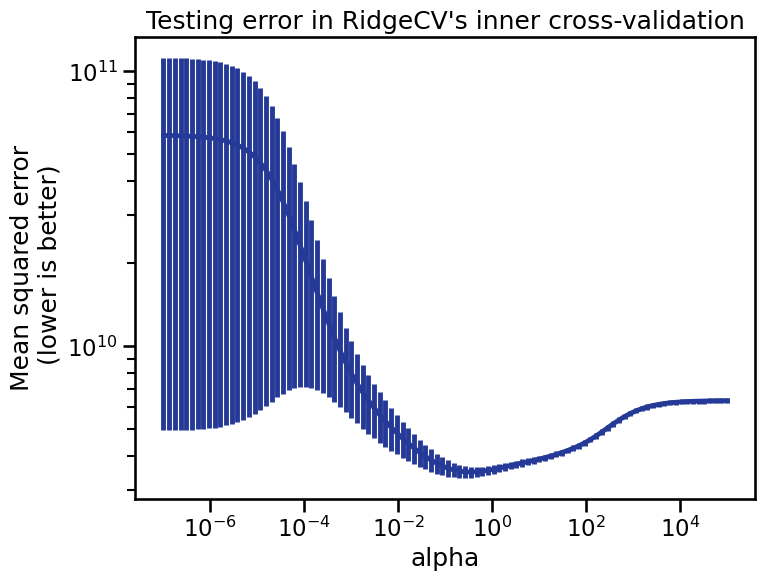

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(cv_alphas.index, cv_alphas["mean"], yerr=cv_alphas["std"])
_ = ax.set(
    xscale="log",
    xlabel="alpha",
    yscale="log",
    ylabel="Mean squared error\n (lower is better)",
    title="Testing error in RidgeCV's inner cross-validation",
)

best_alphas = [est[-1].alpha_ for est in cv_results["estimator"]]
best_alphas

In [36]:
print(
    f"Min optimal alpha: {np.min(best_alphas):.2f} and "
    f"Max optimal alpha: {np.max(best_alphas):.2f}"
)

Min optimal alpha: 0.09 and Max optimal alpha: 0.61
